In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('../datasets/master/master_final_2025.csv')

In [2]:
# Features for clustering: access + outcome + gender gap + library (fill NaN with column mean for the 4 Papua provinces)
feat_cols = ['facility_ratio_jhs','facility_ratio_shs','school_density_primary',
            'library_per_1000pupils','literacy_total','eys_avg','gap_literacy','gap_eys']
X = RobustScaler().fit_transform(df[feat_cols].fillna(df[feat_cols].mean()))

k=4 dipilih untuk interpretabilitas (match 4-kuadran), meski k=2 punya silhouette tertinggi (didominasi 2 outlier ekstrem Papua Tengah/Pegunungan)
{2: 0.599, 3: 0.42, 4: 0.332, 5: 0.385, 6: 0.334, 7: 0.168}


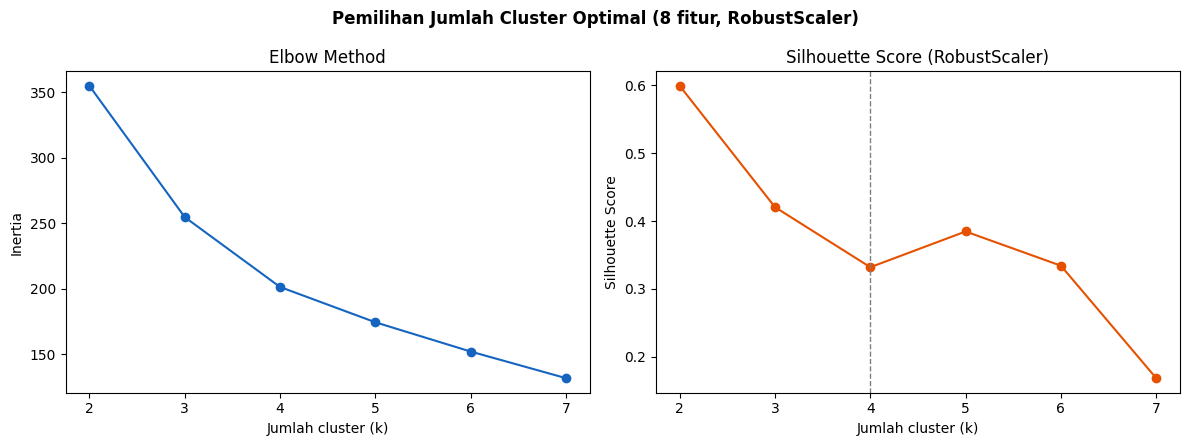

In [3]:
# --- Elbow + Silhouette to pick k ---
inertias, sils = [], []
K = range(2,8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_); sils.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1,2, figsize=(12,4.5))
axes[0].plot(list(K), inertias, 'o-', color='#1565C0')
axes[0].set_xlabel('Jumlah cluster (k)'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(list(K), sils, 'o-', color='#E65100')
axes[1].axvline(4, color='grey', ls='--', lw=1)
axes[1].set_xlabel('Jumlah cluster (k)'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score (RobustScaler)')
plt.suptitle('Pemilihan Jumlah Cluster Optimal (8 fitur, RobustScaler)', fontweight='bold')
plt.tight_layout()
plt.savefig('../src/visualization/06_elbow_silhouette.png', dpi=150)
print('k=4 dipilih untuk interpretabilitas (match 4-kuadran), meski k=2 punya silhouette tertinggi (didominasi 2 outlier ekstrem Papua Tengah/Pegunungan)')
print(dict(zip(K,[round(s,3) for s in sils])))


In [5]:
# PCA for visualization
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)
df['pc1'], df['pc2'] = pcs[:,0], pcs[:,1]
print("PCA explained variance ratio:", pca.explained_variance_ratio_.round(3))

PCA explained variance ratio: [0.411 0.23 ]


In [6]:
# Cluster profile (mean of raw, unstandardized values)
profile = df.groupby('kmeans_cluster')[feat_cols].mean().round(2)
profile['n_provinsi'] = df.groupby('kmeans_cluster').size()
print("\n=== Cluster profile (rata-rata nilai asli) ===")
print(profile)

print("\n=== Anggota tiap cluster ===")
for c in sorted(df['kmeans_cluster'].unique()):
    provs = df[df['kmeans_cluster']==c]['province'].str.title().tolist()
    print(f"Cluster {c} (n={len(provs)}): {provs}")

df.to_csv('../datasets/master/master_final_2025.csv', index=False)


=== Cluster profile (rata-rata nilai asli) ===
                facility_ratio_jhs  facility_ratio_shs  \
kmeans_cluster                                           
0                             0.49                0.22   
1                             0.32                0.10   
2                             0.80                0.51   
3                             0.58                0.24   

                school_density_primary  library_per_1000pupils  \
kmeans_cluster                                                   
0                                 7.49                    0.95   
1                                 4.28                    0.00   
2                                 4.50                    0.84   
3                                 7.28                    6.42   

                literacy_total  eys_avg  gap_literacy  gap_eys  n_provinsi  
kmeans_cluster                                                              
0                        97.83    13.50         -1.5